In [4]:
import pandas as pd
import duckdb as db
import matplotlib.pyplot as plt

In [5]:
chal_playlist_metadata = pd.read_parquet("data/challenge/playlist_metadata.parquet")
chal_playlist_contents = pd.read_parquet("data/challenge/playlist_contents.parquet")
chal_track_metadata = pd.read_parquet("data/challenge/track_metadata.parquet")

train_playlist_metadata = pd.read_parquet("data/original/playlist_metadata.parquet")
train_playlist_contents = pd.read_parquet("data/original/playlist_contents.parquet")
train_track_metadata = pd.read_parquet("data/original/track_metadata.parquet")

In [6]:
# Confirm 10,000 playlists
chal_playlist_metadata["pid"].nunique()

10000

In [7]:
# Determine how many tracks are in the challenge set that aren't in the train set
challenge_tracks = chal_track_metadata["track_uri"].nunique()
chal_and_train_tracks = chal_track_metadata.merge(train_track_metadata, on="track_uri", how="inner")["track_uri"].nunique()
challenge_tracks - chal_and_train_tracks

0

In [8]:
# Understand how many tracks are missing per eval group and their distribution
chal_playlist_metadata["missing_title"] = chal_playlist_metadata["name"] == ""
highest_included_position = chal_playlist_contents.groupby("pid")[["position"]].max().reset_index().rename(columns={"position": "max_pos"})

eval_groups = chal_playlist_metadata.merge(highest_included_position, on="pid", how="left").fillna(-1)
eval_groups['has_random_sample'] = eval_groups['num_samples'] < eval_groups["max_pos"] + 1

db.sql("""
    SELECT missing_title, num_samples, has_random_sample, MIN(num_holdouts) AS min_holdouts, AVG(num_holdouts) AS avg_holdouts, MAX(num_holdouts) AS max_holdouts, MIN(num_tracks), MAX(num_tracks)
    FROM eval_groups
    GROUP BY missing_title, num_samples, has_random_sample
    ORDER BY num_samples
""").df()

,missing_title,num_samples,has_random_sample,min_holdouts,avg_holdouts,max_holdouts,min(num_tracks),max(num_tracks)
0,False,0,False,10,28.604,50,10,50
1,False,1,False,9,22.826,77,10,78
2,False,5,False,5,53.431,95,10,100
3,True,5,False,35,58.067,95,40,100
4,True,10,False,30,53.676,90,40,100
5,False,10,False,30,53.638,90,40,100
6,False,25,True,76,126.773,225,101,250
7,False,25,False,76,125.287,225,101,250
8,False,100,False,50,89.294,150,150,250
9,False,100,True,50,87.570,150,150,250


TypeError: `bins` must be an integer, a string, or an array

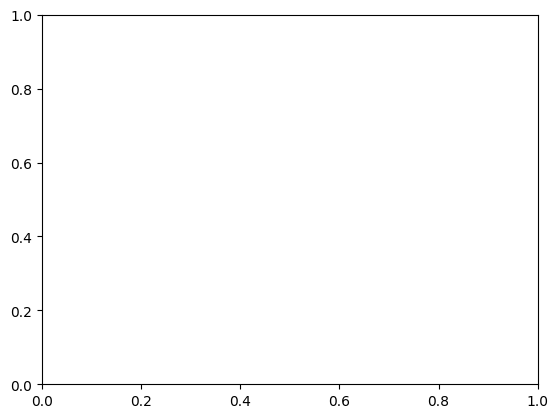

In [9]:
missing_title = False 
num_samples = 25
has_random_sample = False

plot_df = eval_groups[(eval_groups["missing_title"] == missing_title) & (eval_groups["num_samples"] == num_samples) & (eval_groups["has_random_sample"] == has_random_sample)]
plot_df = plot_df[plot_df["num_tracks"] <= 39]
max_length = plot_df["num_tracks"].max()
min_length = plot_df["num_tracks"].min()
plt.hist(plot_df["num_tracks"], bins=max_length-min_length)
plt.show()
train_df = train_playlist_metadata[(train_playlist_metadata["num_tracks"] >= min_length) & (train_playlist_metadata["num_tracks"] <= max_length)]

# first_half = train_df[train_df["num_tracks"] < 50].sample(360)
# second_half = train_df[train_df["num_tracks"] >= 50].sample(640)
# plt.hist(pd.concat([first_half, second_half])["num_tracks"], bins=max_length-min_length)
# plt.show()

plt.hist(train_df.sample(n=1000)["num_tracks"], bins=max_length-min_length)
plt.show()

plt.hist(train_df["num_tracks"], bins=max_length-min_length)
plt.show()

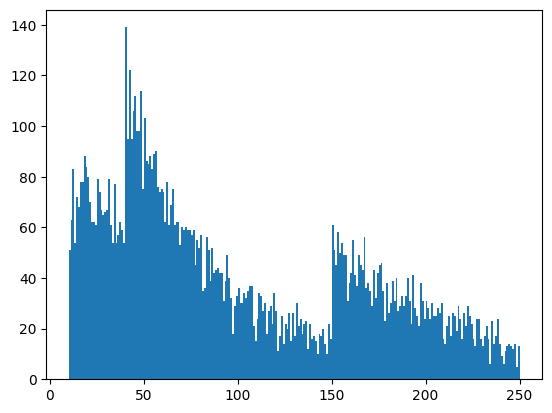

(array([1.1647e+04, 1.5358e+04, 9.0030e+03, 2.1424e+04, 1.2016e+04,
        2.5361e+04, 1.4177e+04, 2.7541e+04, 1.3629e+04, 2.8588e+04,
        2.7478e+04, 1.3149e+04, 2.6281e+04, 1.2834e+04, 2.5015e+04,
        1.2332e+04, 2.4959e+04, 1.1802e+04, 2.3004e+04, 1.1174e+04,
        2.1462e+04, 2.0723e+04, 1.0980e+04, 1.9956e+04, 9.7700e+03,
        1.8842e+04, 9.0050e+03, 1.7537e+04, 8.5020e+03, 1.7200e+04,
        8.0450e+03, 1.5832e+04, 1.5116e+04, 7.2640e+03, 1.4323e+04,
        7.0080e+03, 1.3533e+04, 6.5940e+03, 1.2799e+04, 6.1790e+03,
        1.1815e+04, 5.8400e+03, 1.1483e+04, 1.0830e+04, 5.3130e+03,
        1.0265e+04, 5.0000e+03, 9.6250e+03, 4.8220e+03, 9.4830e+03,
        4.5780e+03, 8.9250e+03, 4.3060e+03, 8.2030e+03, 7.9850e+03,
        3.9320e+03, 7.6550e+03, 3.7290e+03, 7.3380e+03, 3.4700e+03,
        7.0120e+03, 4.4670e+03, 7.1190e+03, 3.4070e+03, 6.5300e+03,
        6.1610e+03, 3.1250e+03, 5.9550e+03, 2.9330e+03, 5.7880e+03,
        2.6400e+03, 5.3040e+03, 2.6730e+03, 5.23

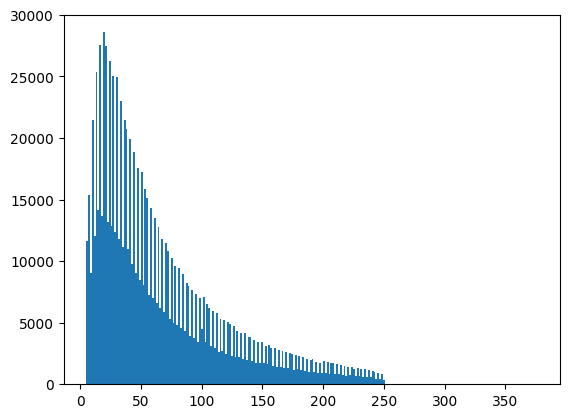

In [ ]:
plt.hist(chal_playlist_metadata["num_tracks"], bins=240)
plt.show()
plt.hist(train_playlist_metadata["num_tracks"], bins=240)

(array([379., 229., 250., 245., 270., 241., 256., 238., 243., 235., 247.,
        236., 226., 262., 254., 240., 262., 254., 249., 223., 250., 251.,
        260., 255., 243., 259., 260., 232., 245., 246., 262., 234., 265.,
        283., 256., 233., 239., 214., 252., 228., 288., 266., 254., 262.,
        244., 240., 280., 237., 243., 205., 294., 242., 252., 265., 220.,
        253., 251., 268., 237., 243., 250., 228., 254., 240., 237., 261.,
        241., 222., 266., 224., 252., 262., 225., 252., 239., 265., 251.,
        236., 233., 241., 252., 234., 240., 236., 257., 248., 234., 286.,
        266., 233., 266., 248., 257., 269., 242., 238., 239., 238., 238.,
        350.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.

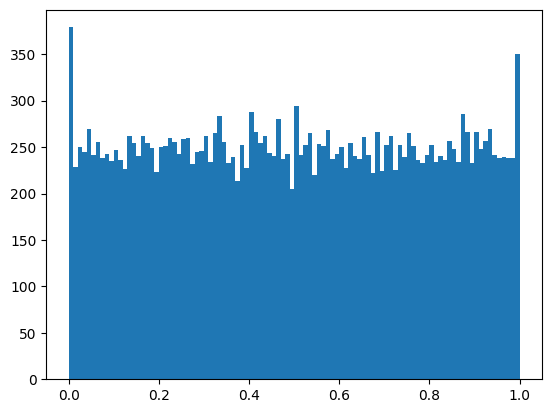

In [ ]:
# understand how the randomly sample ones are actually sampled
random_playlists = eval_groups[(eval_groups["missing_title"] == False) & (eval_groups["num_samples"] == 25) & (eval_groups["has_random_sample"] == True)]
relative_pos_df = db.sql("""
    SELECT p.pid, p.num_tracks, c.position, c.position / (p.num_tracks - 1) AS relative_pos
    FROM random_playlists p
    JOIN chal_playlist_contents c ON p.pid == c.pid
""").df()

plt.hist(relative_pos_df["relative_pos"], bins=100)

In [ ]:
relative_pos_df[(relative_pos_df["relative_pos"] >= 0.99) & (relative_pos_df["relative_pos"] <= 1)]

,pid,num_tracks,position,relative_pos
99,1018569,157,155,0.993590
199,1026975,215,214,1.000000
598,1032006,167,165,0.993976
599,1032006,167,166,1.000000
699,1032023,159,157,0.993671
...,...,...,...,...
99599,1049269,183,182,1.000000
99699,1049300,196,195,1.000000
99799,1049316,211,208,0.990476
99899,1049352,170,169,1.000000
